# Sparse Categorical Cross-entropy Chapter 7 Workshop 3 

## Create load dataset and plotting

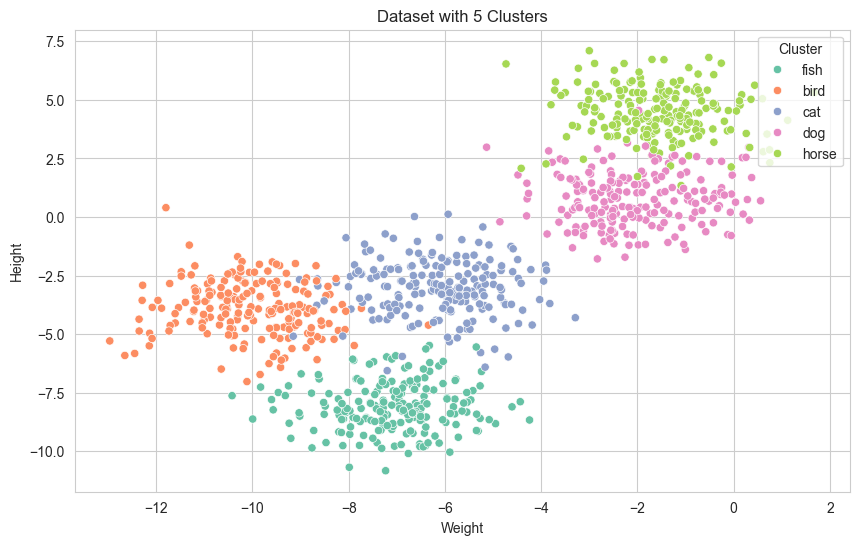

In [6]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Create a dataset with 5 clusters
# with 1000 samples and 2 features
X, y = make_blobs(n_samples=1000, centers=5, n_features=2, cluster_std=1.1 
                  , random_state=1)

X_df = pd.DataFrame(X, columns=['weight', 'height'])
y_df = pd.DataFrame(y, columns=['class'])
df = pd.concat([X_df, y_df], axis=1)

target_map = {
    0: 'horse',
    1: 'bird',
    2: 'fish',
    3: 'cat',
    4: 'dog'
}

# Map the labels to animal names
df['class'] = df['class'].map(target_map)

# Plot the dataset
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weight', y='height', hue='class', palette='Set2')
plt.title('Dataset with 5 Clusters')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.legend(title='Cluster', loc='upper right')
plt.show()

In [12]:
class_names, y = np.unique(df['class'], return_inverse=True)
print(class_names)
print(y)

['bird' 'cat' 'dog' 'fish' 'horse']
[3 0 1 1 2 2 3 2 2 2 2 4 4 1 0 1 4 2 2 0 1 2 1 4 1 3 1 2 0 1 0 3 3 1 4 2 0
 0 1 0 3 4 4 4 2 1 3 0 3 2 1 3 0 2 0 1 0 1 4 0 2 0 1 4 4 2 0 4 4 2 0 3 1 2
 1 3 3 2 1 0 3 1 2 0 2 2 4 3 3 4 0 3 3 2 4 4 2 1 2 4 3 4 2 2 1 1 4 1 4 1 4
 1 3 1 4 3 3 4 0 4 0 3 2 4 3 2 1 2 4 2 3 4 2 0 2 1 2 0 1 3 1 3 0 0 0 3 0 1
 2 0 0 1 4 2 4 1 4 0 0 2 2 3 1 0 4 0 2 1 4 0 3 2 1 1 3 3 0 3 1 2 0 3 0 1 0
 0 1 4 1 1 3 4 4 1 3 2 0 4 0 0 4 3 1 1 1 3 2 1 1 4 0 4 2 4 0 0 3 1 3 4 3 4
 3 1 3 2 4 1 4 3 0 0 0 0 2 0 4 2 4 3 2 4 4 3 2 4 4 3 1 0 0 4 3 2 0 4 0 3 0
 4 3 1 4 1 0 2 0 3 3 3 3 1 4 2 1 2 1 4 4 3 0 3 4 3 4 0 1 1 4 1 3 2 1 4 4 0
 2 4 1 3 2 4 3 0 3 3 3 3 1 0 0 1 0 0 4 4 1 2 2 4 1 1 0 3 4 4 1 2 0 2 0 1 2
 2 1 3 1 4 3 4 3 0 0 2 4 1 2 3 2 2 1 3 2 0 2 2 3 1 4 1 3 1 2 0 2 2 3 3 1 1
 3 3 2 0 0 1 4 4 4 3 2 2 4 3 3 3 2 0 1 2 0 4 1 4 0 4 2 1 3 1 3 2 1 1 2 1 3
 2 3 1 4 3 2 0 1 2 1 3 4 0 1 3 2 1 0 4 4 0 2 1 4 0 0 0 1 1 2 4 1 1 3 2 0 2
 2 3 4 2 4 3 4 1 2 3 1 3 4 0 3 1 4 2 3 2 4 0 3 1 3 2 4 3 3 3 3 3

## Prepare Data

### Prepare feature X

In [9]:
X = df.drop(columns=['class'])
X.sample(5, random_state=1)

,weight,height
507,-0.976369,5.458224
818,0.596731,5.050718
452,-3.233872,0.496238
368,-5.541547,-4.778113
242,-1.117990,3.657744


### Standard Scalar

In [10]:
from sklearn.preprocessing import StandardScaler
# Standardize the features
sc = StandardScaler()
X_sc = sc.fit_transform(X)
X_sc[:5]

array([[-0.5595291 , -1.35408313],
       [-2.10518858, -0.87283448],
       [-0.17865988, -0.29606987],
       [ 0.0185207 , -0.22299352],
       [ 1.04534643,  0.78033742]])

### Split Train and Test data

In [13]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets (75:25)
X_train, X_test, y_train, y_test = train_test_split(X_sc, y, 
                                                    test_size=0.25, 
                                                    random_state=1)
X_train.shape, X_test.shape

((750, 2), (250, 2))

## Create Model

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Create a Sequential model
model = Sequential()
# Add a Dense layer with 5 neurons and ReLU activation function 2 input features
model.add(Dense(100, activation='relu', input_shape=(X_train.shape[1],)))

# Output layer with softmax activation function 5 neurons
model.add(Dense(5, activation='softmax')) # Use softmax for multi-class classification

## Compile model

In [31]:
model.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=20, 
                    validation_split=0.25, 
                    verbose=1)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2962 - loss: 1.5461 - val_accuracy: 0.6862 - val_loss: 1.3276
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6998 - loss: 1.2498 - val_accuracy: 0.6755 - val_loss: 1.1063
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6577 - loss: 1.0620 - val_accuracy: 0.6968 - val_loss: 0.9500
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7140 - loss: 0.8767 - val_accuracy: 0.7287 - val_loss: 0.8275
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7324 - loss: 0.8085 - val_accuracy: 0.7553 - val_loss: 0.7325
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7882 - loss: 0.7075 - val_accuracy: 0.7926 - val_loss: 0.6507
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8037 - loss: 0.6366 - val_accuracy: 0.8298 - val_loss: 0.5800
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8632 - loss: 0.5335 - val_accuracy: 0.8617 - val_loss:

### Check score model 

In [33]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {score[0]}')
print(f'Test accuracy: {score[1]}')

Test loss: 0.10221461206674576
Test accuracy: 0.972000002861023


## Predict

In [34]:
y_pred = model.predict(X_test)

y_pred[:4].round(3)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


array([[0.   , 0.   , 0.004, 0.   , 0.996],
       [0.   , 0.   , 0.011, 0.   , 0.989],
       [0.   , 0.015, 0.965, 0.   , 0.02 ],
       [0.001, 0.926, 0.005, 0.068, 0.   ]], dtype=float32)

## Create one-hot function

In [35]:
class Onehot2int(object):
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_pred = self.model.predict(X)
        # Convert the predicted probabilities to one-hot encoding
        return np.argmax(y_pred, axis=1)
# Create an instance of the Onehot2int class
model_no_ohe = Onehot2int(model)

## Model Boundary Plotting

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 471us/step


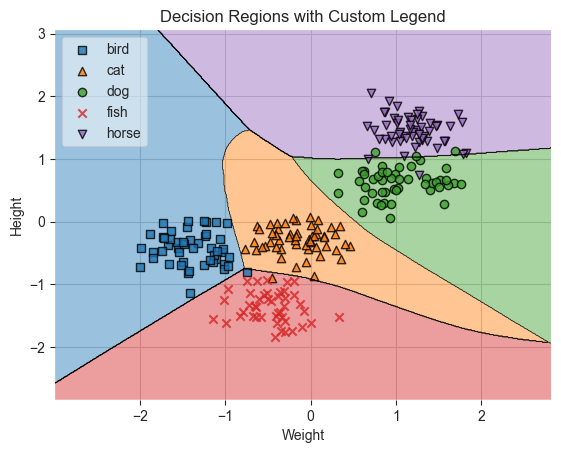

In [36]:
from mlxtend.plotting import plot_decision_regions
ax = plot_decision_regions(X_test, y_test, clf=model_no_ohe,)

handles, labels = ax.get_legend_handles_labels()
# Create a custom legend
ax.legend(handles, class_names, framealpha=0.5)
plt.title('Decision Regions with Custom Legend')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

# SGD with Momentum Chapter 7 Workshop 8

## Create model

In [61]:
# Create a Sequential model
model = Sequential()
# Add a Dense layer with 100 neurons and ReLU activation function 2 input features
model.add(Dense(100, activation='relu', input_shape=(X_train.shape[1],)))
# Softmax activation function 5 neurons
model.add(Dense(5, activation='softmax')) # Use softmax for multi-class classification

## Compile model 

### Compile with default SGD

In [50]:
# Compile the model with default SGD
model.compile(optimizer='SGD',
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### Compile with specified SGD

In [54]:
import tensorflow as tf
# Specify the optimizer with momentum
opt = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=opt,
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### Compile with RMSprop

In [58]:
# Compile the model with RMSprop
model.compile(optimizer='RMSprop',
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### Compile with Adam

In [62]:
# Compile the model with Adam
model.compile(optimizer='Adam',
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## Train model

In [63]:
history = model.fit(X_train, y_train,
                    epochs=200, 
                    batch_size=32, 
                    validation_split=0.25, 
                    verbose=1)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2130 - loss: 1.6255 - val_accuracy: 0.3936 - val_loss: 1.4610
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4920 - loss: 1.3899 - val_accuracy: 0.5160 - val_loss: 1.2808
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5429 - loss: 1.2323 - val_accuracy: 0.5745 - val_loss: 1.1230
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6026 - loss: 1.0699 - val_accuracy: 0.6596 - val_loss: 0.9922
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6492 - loss: 0.9613 - val_accuracy: 0.6915 - val_loss: 0.8865
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6808 - loss: 0.8674 - val_accuracy: 0.7181 - val_loss: 0.8036
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7300 - loss: 0.7403 - val_accuracy: 0.7340 - val_loss: 0.7352
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7824 - loss: 0.6885 - val_accuracy: 0.7500 - v

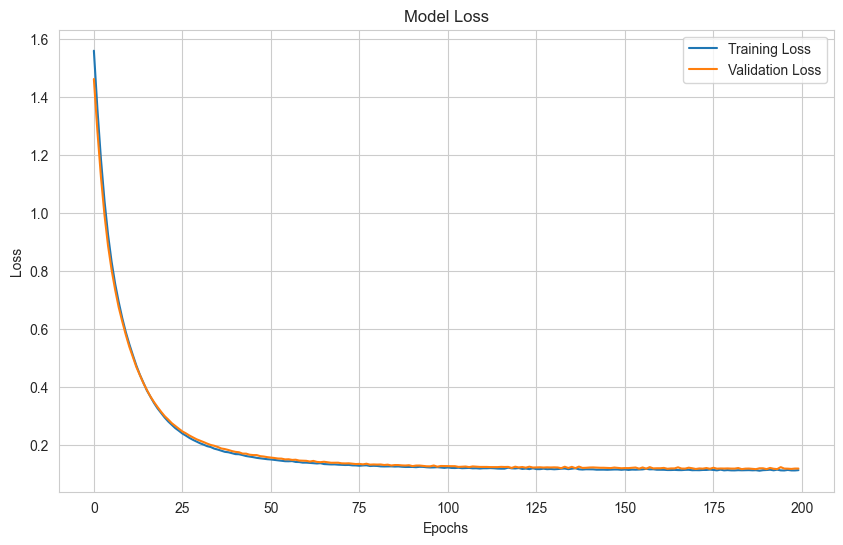

In [64]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()